In [ ]:
import pandas as pd
import requests
from bs4 import BeautifulSoup

In [ ]:
urls = [
    "https://zoon.ru/msk/business/type/svedenie_i_mastering/",
    "https://zoon.ru/msk/business/type/studii_zvukozapisi/",
    "https://zoon.ru/msk/business/type/studii_zvukozapisi/?v%5B4f84a6953c72ddd76600000c%5D%5Bкруглосуточно%5D=круглосуточно&search_query_form=1",
    "https://zoon.ru/msk/business/type/studii_zvukozapisi/?require_org_link=true&search_query_form=1",
    "https://zoon.ru/msk/business/type/svedenie_i_mastering/page-2/?v%5B4f84a6953c72ddd76600000c%5D%5B2%5D=2&search_query_form=1"

]

headers = {
    "User-Agent": "Mozilla/5.0"
}
all_reviews = []
for url in urls:

    response = requests.get(url, headers=headers)

    soup = BeautifulSoup(response.text, "html.parser")

    reviews = soup.find_all("div", class_="minicard-item__comment z-mt--8")

    for review in reviews:
        text = review.text.strip()

        all_reviews.append(text)

    print(f"Собрано отзывов: {len(all_reviews)}")

df = pd.DataFrame({
    "review": all_reviews
})


df = df.drop_duplicates()

Собрано отзывов: 29
Собрано отзывов: 58
Собрано отзывов: 80
Собрано отзывов: 83
Собрано отзывов: 100


In [ ]:
len(df)

74

In [ ]:
texts = []

for review in reviews:
    texts.append(review.text.strip())


In [ ]:
df = pd.DataFrame({
    "review": texts
})

df.head()

,review
0,Очень качественная студия. Максимально клиенто...
1,"Для меня это лучшая студия, в которой приходил..."
2,"Я рада, что обратилась в данную компанию. Мне ..."
3,Очень красивое и комфортное место. Много разно...
4,"Записали на студии уже три трека, результат от..."


In [ ]:
df["review"] = df["review"].str.replace("\xa0", " ")

In [ ]:
df.to_csv("reviews.csv", index=False)

In [ ]:
from collections import Counter
import re

In [ ]:
all_text = " ".join(df["review"])

all_text = all_text.lower()

words = re.findall(r"\b[а-яё]+\b", all_text)

In [ ]:
stopwords = [
    "и", "в", "на", "с", "что", "это", "очень", 'как', 'так', 'мне',
    "все", "для", "по", "но", "не", "а", "из", 'раз', 'всё',
    "к", "у", "же", "бы", "то", "от", "до", 'студия', 'звукозаписи', 'студии', 'студию',
    'спасибо'
]

filtered_words = [
    word for word in words
    if word not in stopwords and len(word) > 2
]

In [ ]:
word_counts = Counter(filtered_words)

word_counts.most_common(20)

[('сделали', 3),
 ('записи', 3),
 ('место', 3),
 ('работы', 2),
 ('качество', 2),
 ('супер', 2),
 ('можно', 2),
 ('оборудования', 2),
 ('сразу', 2),
 ('приятная', 2),
 ('атмосфера', 2),
 ('уже', 2),
 ('отличный', 2),
 ('профессионалы', 2),
 ('рекомендую', 2),
 ('оборудование', 2),
 ('цена', 2),
 ('репетиции', 2),
 ('отличная', 2),
 ('комнаты', 2)]

In [ ]:
import matplotlib.pyplot as plt

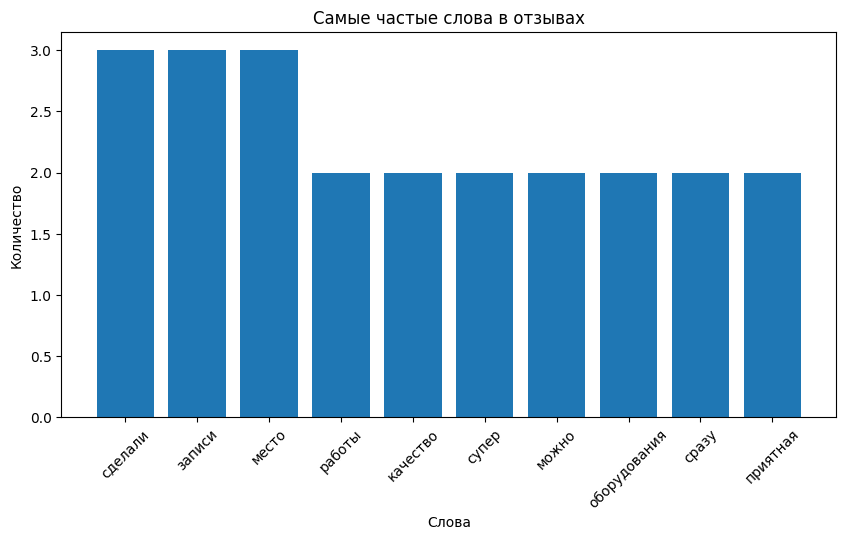

In [ ]:
top_words = word_counts.most_common(10)

words = [word[0] for word in top_words]
counts = [word[1] for word in top_words]

plt.figure(figsize=(10,5))
plt.bar(words, counts)

plt.title("Самые частые слова в отзывах")
plt.xlabel("Слова")
plt.ylabel("Количество")

plt.xticks(rotation=45)

plt.show()